# Detección de fraude: modelado

## Objetivo

* Entrenar un modelo que detecte transacciones fraudulentas con **AUC-PR, F1 y F2 mayores a 0.75**.
* El F2 le da más peso al recall: para un banco es peor dejar pasar un fraude que revisar una transacción normal.

## 1. Librerías

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sys.path.append(str(Path("..").resolve()))
from src.data.data_clean import clean_data, drop_unnecessary_columns, load_data
from src.features.engineering import add_features
from src.modeling.models import evaluate, scores_by_threshold
from src.preprocessing.preprocessing import create_preprocessor

RANDOM_STATE = 42
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## 2. Carga y preparación de datos

In [2]:
def prepare(file_name):
    df = load_data(file_name)
    df = clean_data(df)
    df = add_features(df)
    return drop_unnecessary_columns(df)


train = prepare("fraudTrain.csv")
test = prepare("fraudTest.csv")

print("Entrenamiento:", train.shape, "desde", train["trans_date_trans_time"].min().date(), "hasta", train["trans_date_trans_time"].max().date())
print("Prueba:", test.shape, "desde", test["trans_date_trans_time"].min().date(), "hasta", test["trans_date_trans_time"].max().date())

Entrenamiento: (1296675, 10) desde 2019-01-01 hasta 2020-06-21
Prueba: (555719, 10) desde 2020-06-21 hasta 2020-12-31


* Kaggle ya separa los datos por fecha: entrenamiento hasta junio 2020 y prueba de junio a diciembre 2020. Así simulamos el caso real, donde el modelo se entrena con el pasado y se usa en el futuro.
* Para comparar modelos necesitamos un conjunto de **validación**. Como los datos tienen orden en el tiempo, no los separamos al azar: usamos el **último 20%** de entrenamiento (por fecha) como validación.

In [3]:
numerical_cols = ["amt", "age", "hour", "day_of_week", "distance_km", "city_pop"]
categorical_cols = ["category", "gender"]
features = numerical_cols + categorical_cols

split = int(len(train) * 0.8)  # train ya está ordenado por fecha
train_part, valid = train.iloc[:split], train.iloc[split:]

X_train, y_train = train_part[features], train_part["is_fraud"]
X_valid, y_valid = valid[features], valid["is_fraud"]

print(f"Entrenamiento: {len(X_train)} filas, {y_train.sum()} fraudes")
print(f"Validación: {len(X_valid)} filas, {y_valid.sum()} fraudes")

Entrenamiento: 1037340 filas, 5968 fraudes
Validación: 259335 filas, 1538 fraudes


## 3. Comparación de modelos

* Probamos 4 modelos. Todos usan el mismo preprocesamiento dentro de un `Pipeline` (escalado y one-hot encoding).
* Para el desbalance usamos `class_weight="balanced"` en la regresión logística y `scale_pos_weight` en XGBoost, que le dan más peso a los fraudes.
* El `DummyClassifier` es la referencia: su AUC-PR es igual a la proporción de fraude.

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Dummy": DummyClassifier(strategy="prior"),
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight, n_jobs=-1, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    pipeline = Pipeline([("prep", create_preprocessor(categorical_cols, numerical_cols)), ("model", model)])
    pipeline.fit(X_train, y_train)
    results[name] = evaluate(y_valid, pipeline.predict_proba(X_valid)[:, 1])

results = pd.DataFrame(results).T
results.round(3)

,AUC-PR,F1,F2,Recall,Precisión
Dummy,0.006,0.000,0.000,0.000,0.000
LogisticRegression,0.169,0.068,0.150,0.757,0.036
RandomForest,0.916,0.859,0.802,0.768,0.974
XGBoost,0.906,0.796,0.844,0.880,0.727


* El Dummy tiene un AUC-PR de 0.006, que es justo la proporción de fraude. Todos los modelos le ganan.
* La regresión logística queda muy baja (AUC-PR de 0.17). El fraude depende de combinaciones entre hora, monto y categoría (por ejemplo, montos altos de noche en compras por internet) y un modelo lineal no capta bien eso.
* **Random Forest** tiene el mejor AUC-PR (0.916) y el mejor F1 (0.86). XGBoost queda muy cerca (0.906) y con más recall, porque `scale_pos_weight` lo hace más agresivo para marcar fraudes.
* Seguimos con Random Forest porque el AUC-PR es nuestra métrica principal.

## 4. Ajuste de Random Forest

* Probamos algunos valores de `min_samples_leaf` (mínimo de transacciones en cada hoja del árbol) y `n_estimators`, y nos quedamos con el que tenga mejor AUC-PR en validación.
* No usamos GridSearchCV con validación cruzada porque con más de un millón de filas cada entrenamiento tarda cerca de un minuto, y además la validación cruzada mezclaría fechas.

In [5]:
tuning = []
for n_estimators in [100, 200]:
    for min_samples_leaf in [1, 5, 10]:
        rf = RandomForestClassifier(
            n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, n_jobs=-1, random_state=RANDOM_STATE
        )
        pipeline = Pipeline([("prep", create_preprocessor(categorical_cols, numerical_cols)), ("model", rf)])
        pipeline.fit(X_train, y_train)
        proba = pipeline.predict_proba(X_valid)[:, 1]
        tuning.append({
            "n_estimators": n_estimators,
            "min_samples_leaf": min_samples_leaf,
            "AUC-PR": evaluate(y_valid, proba)["AUC-PR"],
        })

tuning = pd.DataFrame(tuning).sort_values("AUC-PR", ascending=False)
tuning.round(4)

,n_estimators,min_samples_leaf,AUC-PR
3,200,1,0.9190
4,200,5,0.9168
1,100,5,0.9157
0,100,1,0.9153
5,200,10,0.9101
2,100,10,0.9098


* Las diferencias son pequeñas (de 0.910 a 0.919). El mejor resultado es con 200 árboles y `min_samples_leaf=1`, así que usamos esa configuración.

In [6]:
best_rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=1, n_jobs=-1, random_state=RANDOM_STATE)
best_pipeline = Pipeline([("prep", create_preprocessor(categorical_cols, numerical_cols)), ("model", best_rf)]).fit(X_train, y_train)

## 5. Umbral de decisión

* Probamos umbrales de 0.1 a 0.9 con los datos de validación y elegimos el que da mejor F2, siempre que el F1 también quede por encima de 0.75.

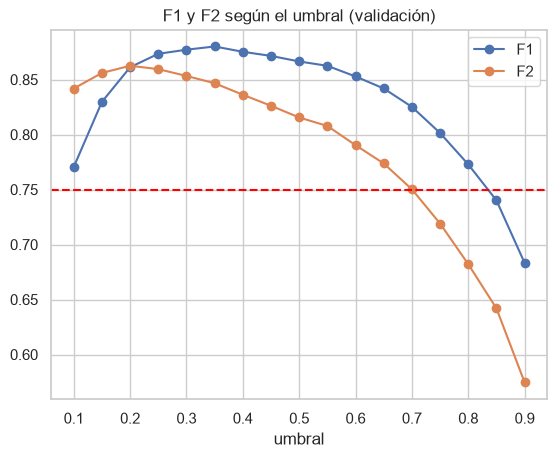

umbral,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90
F1,0.771,0.830,0.861,0.873,0.877,0.880,0.875,0.872,0.866,0.863,0.853,0.842,0.825,0.801,0.773,0.740,0.683
F2,0.842,0.856,0.863,0.860,0.853,0.847,0.836,0.826,0.816,0.808,0.790,0.774,0.750,0.719,0.682,0.642,0.575


In [7]:
valid_proba = best_pipeline.predict_proba(X_valid)[:, 1]
threshold_scores = scores_by_threshold(y_valid, valid_proba)

threshold_scores.plot(marker="o", title="F1 y F2 según el umbral (validación)")
plt.axhline(0.75, color="red", linestyle="--")
plt.show()

threshold_scores.round(3).T

* El mejor F2 (0.86) se obtiene con un umbral de **0.2**, y con ese umbral el F1 también es alto (0.86).
* Bajar el umbral de 0.5 a 0.2 hace que el modelo marque más transacciones como fraude: detecta más fraudes (sube el recall) a cambio de algunas falsas alarmas más.

In [8]:
best_threshold = threshold_scores["F2"].idxmax()
print("Umbral elegido:", best_threshold)

Umbral elegido: 0.2


## 6. Evaluación final con los datos de prueba

* Volvemos a entrenar el modelo con **todo** el archivo de entrenamiento (entrenamiento + validación) y lo evaluamos una sola vez con `fraudTest.csv`.

In [9]:
final_model = Pipeline([("prep", create_preprocessor(categorical_cols, numerical_cols)), ("model", best_rf)])
final_model.fit(train[features], train["is_fraud"])

test_proba = final_model.predict_proba(test[features])[:, 1]
final_results = pd.DataFrame({
    "Umbral 0.5": evaluate(test["is_fraud"], test_proba, 0.5),
    f"Umbral {best_threshold}": evaluate(test["is_fraud"], test_proba, best_threshold),
}).T
final_results.round(3)

,AUC-PR,F1,F2,Recall,Precisión
Umbral 0.5,0.881,0.845,0.795,0.765,0.945
Umbral 0.2,0.881,0.818,0.835,0.847,0.791


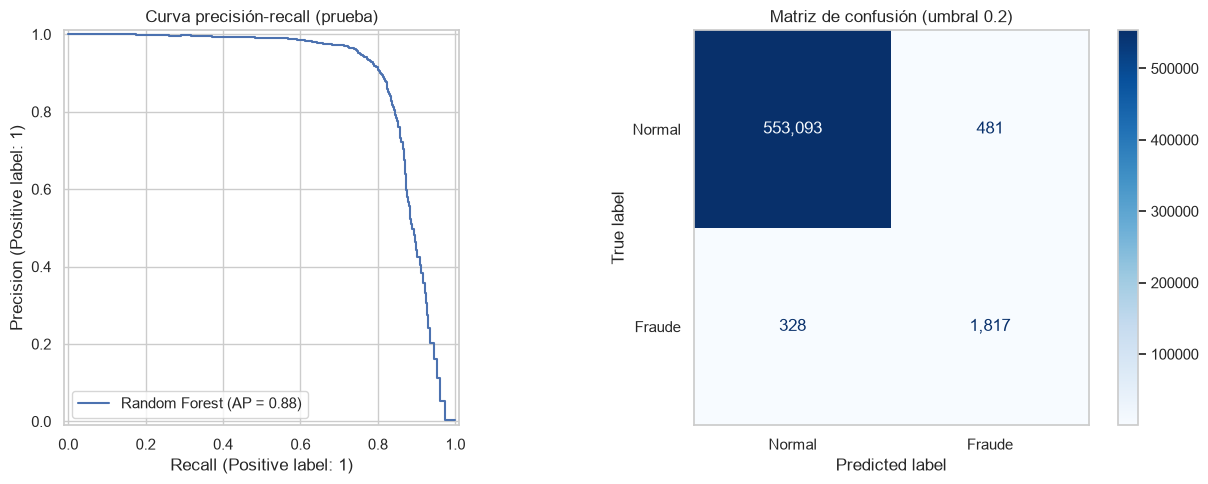

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
PrecisionRecallDisplay.from_predictions(test["is_fraud"], test_proba, name="Random Forest", ax=axes[0])
axes[0].set_title("Curva precisión-recall (prueba)")

ConfusionMatrixDisplay.from_predictions(
    test["is_fraud"], (test_proba >= best_threshold).astype(int),
    display_labels=["Normal", "Fraude"], cmap="Blues", values_format=",", ax=axes[1],
)
axes[1].set_title(f"Matriz de confusión (umbral {best_threshold})")
axes[1].grid(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "resultados_prueba.png", dpi=100, bbox_inches="tight")
plt.show()

### 6.1 Variables más importantes

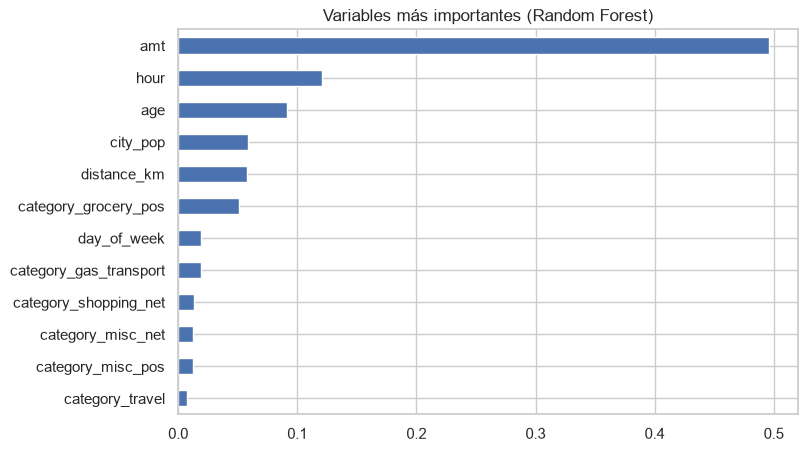

In [11]:
feature_names = final_model.named_steps["prep"].get_feature_names_out()
importance = pd.Series(final_model.named_steps["model"].feature_importances_, index=feature_names)
importance.index = importance.index.str.replace("num__", "").str.replace("cat__", "")

importance.sort_values().tail(12).plot(kind="barh", figsize=(8, 5), title="Variables más importantes (Random Forest)")
plt.show()

## 7. Conclusiones

* El modelo final es un **Random Forest** (200 árboles) con un umbral de **0.2**. Con los datos de prueba (junio a diciembre 2020) obtiene:

| Métrica | Valor | Meta |
|---|---|---|
| AUC-PR | 0.88 | > 0.75 ✔ |
| F1 | 0.82 | > 0.75 ✔ |
| F2 | 0.84 | > 0.75 ✔ |
| Recall | 0.85 | |
| Precisión | 0.79 | |

* De 2145 fraudes, el modelo detecta **1817** y se le escapan 328. A cambio, marca 481 transacciones normales como sospechosas, de un total de más de 553 mil.
* Las métricas en prueba son un poco más bajas que en validación (AUC-PR de 0.88 frente a 0.92). Es normal porque son meses más nuevos y con menos fraude (0.39% frente a 0.58%).
* Las variables más importantes son el **monto**, la **hora** y la **edad**, lo que coincide con lo que vimos en el EDA. `city_pop` y `distance_km` también aparecen, pero hay que tener cuidado: la importancia de Random Forest tiende a favorecer a las variables numéricas con muchos valores distintos.

**Lo que aprendí:**

* Con datos que tienen orden en el tiempo, la validación debe respetar las fechas (entrenar con el pasado y validar con lo más reciente).
* Con clases tan desbalanceadas, el umbral de decisión importa mucho: pasar de 0.5 a 0.2 subió el recall de 0.77 a 0.85.
* Revisar bien las gráficas del EDA: en la primera versión conté todas las transacciones en lugar de los fraudes y saqué una conclusión equivocada sobre la hora.

**Recomendaciones para el banco:**

* Revisar con más cuidado las transacciones de **montos altos entre las 22:00 y las 4:00**, sobre todo en compras por internet (`shopping_net`, `misc_net`).
* Revisar las 481 falsas alarmas para ver si se puede ajustar el umbral según el costo real de bloquear a un cliente frente al costo de un fraude.
* Como siguiente paso, se podrían agregar variables por cliente, por ejemplo cuánto se aleja el monto de lo que ese cliente gasta normalmente.